# 01 · Create Synthetic Data — Beverage Supply Chain

**Pre-Hackathon Enablement · Notebook 1 of 6**

The starting point for the whole series. We generate a small, realistic
**Anheuser-Busch beverage distribution / supply-chain** dataset and land it as
governed **Delta tables** in Unity Catalog. Every later notebook builds on these
exact tables.

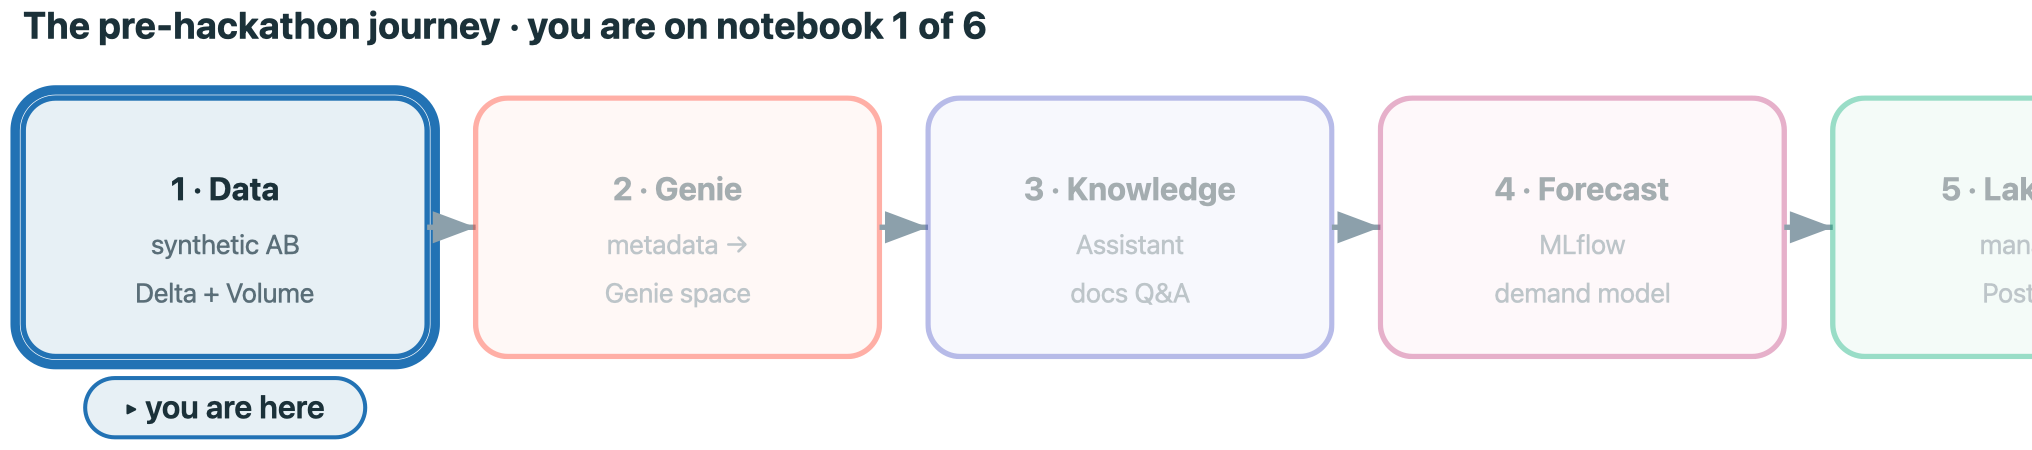

### What you'll learn
- How source data becomes **Delta tables under Unity Catalog** (`catalog.schema.table`)
- A clean, join-friendly star schema that Genie can reason over (Notebook 2)
- Writing reproducible synthetic data with a fixed random seed
- Landing **unstructured docs in a UC Volume** — policy/SOP PDFs for the
  **Agent Bricks Knowledge Assistant** in Notebook 3

### Why synthetic data?
We want a dataset that is **realistic, shareable, and identical for everyone** —
no customer data, no access requests. A fixed seed means every participant's
tables (and later, Genie answers) come out the same.

### The data model
Two **dimensions** (things we describe) and two **facts** (things that happen) —
a deliberately Genie-friendly star: clear keys, obvious joins, one grain per table.

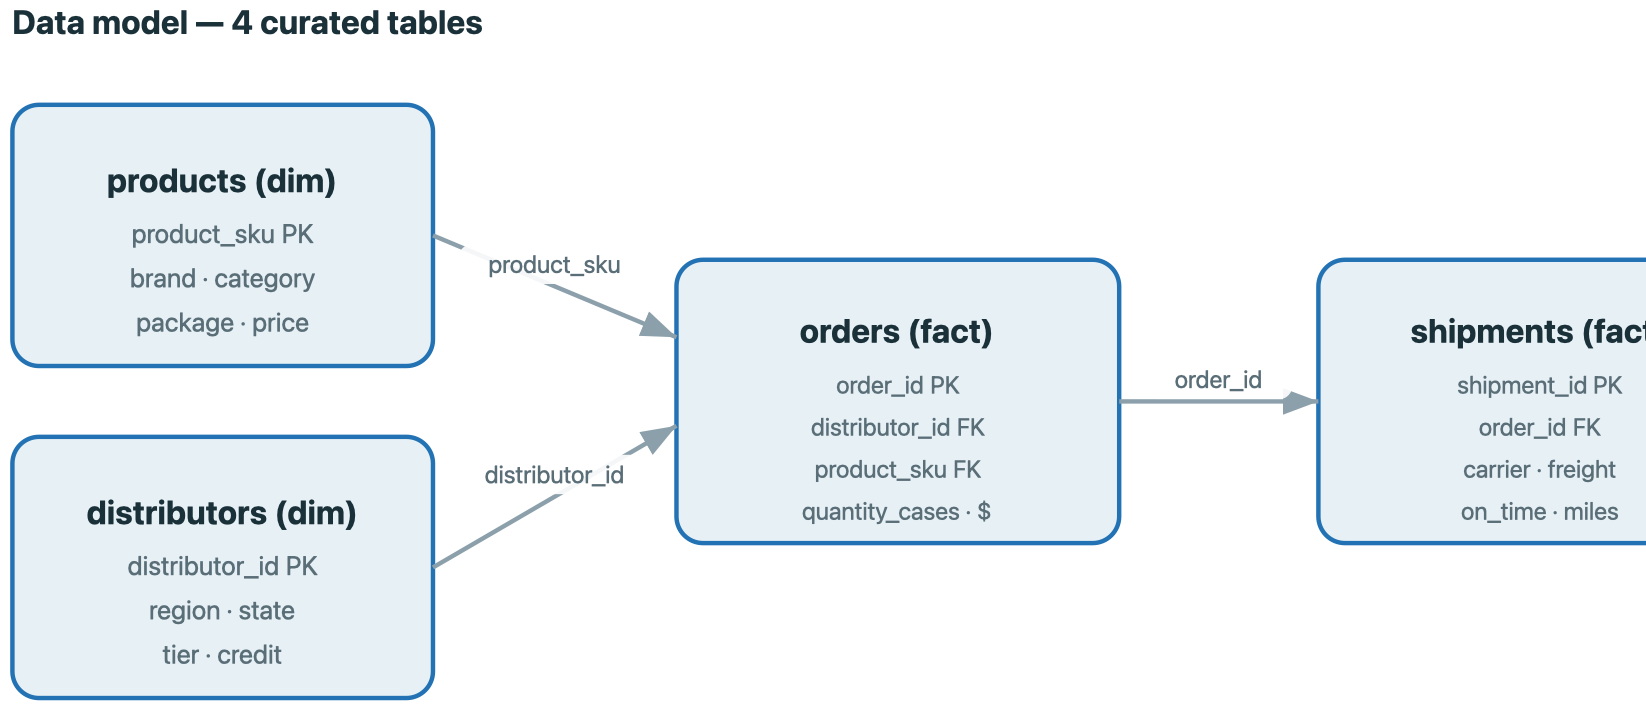

- **products** — sellable SKUs (an AB brand in a package) · dimension
- **distributors** — who we sell to, by US region · dimension
- **orders** — cases ordered by a distributor for a product · fact (grain = order line)
- **shipments** — how each order moved, freight, on-time performance · fact (grain = shipment)

> **Prerequisites:** any UC-enabled workspace with a running cluster/serverless.
> You need permission to **create a Volume** in your schema (Step 5); that step
> installs `reportlab` to render the PDFs. No other SDK or entitlements needed.

> ### 👥 Running this with several people on one workspace?
> **Give each person their own schema** so you don't overwrite each other's
> tables. Set the `schema` widget to something unique like `abi_<yourname>`.
> Use the *same* catalog/schema in every later notebook.

## Step 1 · Parameters

Use notebook **widgets** so you never edit code — and so each participant can
point at their **own** catalog/schema.

**Run the cell below once to create the widgets**, then set them at the top of the
notebook:
- **catalog** — an **existing** Unity Catalog catalog you can create schemas in.
  You typically *won't* have permission to create a catalog, so enter one your
  workspace already provides (ask your admin if unsure). We do **not** create it.
- **schema** — a **base** name. The notebook **automatically appends your username**
  (e.g. `abi_hackathon_jsmith`), so it's unique per person with no manual naming and
  no collisions when several people share a catalog. Every notebook derives the
  **same** name for you, so you don't re-enter it.

In [ ]:
# Widgets only — run this cell, then set the values in the widget bar up top.
dbutils.widgets.text("catalog", "technology_dev", "Unity Catalog catalog (must already exist)")
dbutils.widgets.text("schema", "abi_hackathon", "Schema base (your username is appended)")

Now read the widgets and create **just the schema** inside your chosen catalog.

In [ ]:
import re
CATALOG = dbutils.widgets.get("catalog").strip()

# Auto-append your username so each participant gets a unique schema (no manual
# uniqueness, no collisions when sharing a catalog). It's derived from your
# Databricks identity and is deterministic, so every notebook resolves to the
# SAME schema for you — you never have to re-enter it.
_user = spark.sql("SELECT current_user()").collect()[0][0]
_slug = re.sub(r"[^a-z0-9]+", "_", _user.split("@")[0].lower()).strip("_")
# Idempotent: if the base already ends with your slug (e.g. you re-ran), don't double it.
_base = dbutils.widgets.get("schema").strip()
_base = _base[:-(len(_slug) + 1)] if _base.endswith("_" + _slug) else _base
SCHEMA = f"{_base}_{_slug}"
FQ = f"{CATALOG}.{SCHEMA}"
print(f"User:            {_user}")
print(f"Schema (in use): {SCHEMA}   ← base '{_base}' + your username '{_slug}'")
print(f"Full target:     {FQ}")
print("(The 'schema' widget stays the base name; the username is appended here in code.)")

# We do NOT create the catalog — enter an existing one you can use. We only create
# the schema inside it. If the catalog isn't accessible, you'll get a clear message.
try:
    spark.sql(f"USE CATALOG {CATALOG}")
except Exception as e:
    raise RuntimeError(
        f"Catalog '{CATALOG}' isn't accessible. Set the `catalog` widget to a Unity "
        f"Catalog catalog you can use (with CREATE SCHEMA rights), then re-run."
    ) from e
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {FQ}")
spark.sql(f"USE {FQ}")
print(f"Using {FQ}")

## Step 2 · Generate the data

Everything is seeded (`np.random.seed(42)`) so the dataset is **identical for
every participant**. We build four pandas DataFrames — two **dimensions**
(`products`, `distributors`) and two **facts** (`orders`, `shipments`) — then write
them to Delta in Step 3.

The cell below first defines the **reference lists** every table draws from: the
real Anheuser-Busch **brands** (grouped into commercial **segments** — Core,
Premium, Value, Craft & Import, Non-Alcoholic), **package** types, **regions/
states**, distributor **tiers**, and carriers. Sourcing everything from these keeps
the tables — and the Genie questions you'll ask later — internally consistent.

In [ ]:
import numpy as np
import pandas as pd
from datetime import date, timedelta

np.random.seed(42)

# ---- Reference lists -----------------------------------------------------
REGIONS = {
    "Northeast": ["NY", "MA", "PA", "NJ"],
    "Southeast": ["FL", "GA", "NC", "TN"],
    "Midwest":   ["IL", "OH", "MI", "WI"],
    "West":      ["CA", "WA", "OR", "NV"],
    "Southwest": ["TX", "AZ", "CO", "NM"],
}
CITY_BY_STATE = {
    "NY": "New York", "MA": "Boston", "PA": "Philadelphia", "NJ": "Newark",
    "FL": "Miami", "GA": "Atlanta", "NC": "Charlotte", "TN": "Nashville",
    "IL": "Chicago", "OH": "Columbus", "MI": "Detroit", "WI": "Milwaukee",
    "CA": "Los Angeles", "WA": "Seattle", "OR": "Portland", "NV": "Las Vegas",
    "TX": "Dallas", "AZ": "Phoenix", "CO": "Denver", "NM": "Albuquerque",
}
DCS = {
    "Northeast": "Newark DC", "Southeast": "Atlanta DC", "Midwest": "Chicago DC",
    "West": "Los Angeles DC", "Southwest": "Dallas DC",
}
CARRIERS = ["Ironhorse Freight", "BlueLine Logistics", "Sunbelt Carriers", "Regional Express"]

# brand -> category. Real Anheuser-Busch portfolio, grouped into commercial
# segments (a natural dimension for Genie questions like "sales by segment").
BRANDS = {
    "Budweiser":               "Core",
    "Bud Light":               "Core",
    "Bud Ice":                 "Value",
    "Busch":                   "Value",
    "Busch Light":             "Value",
    "Natural Light":           "Value",
    "Natural Ice":             "Value",
    "Natty Daddy":             "Value",
    "Rolling Rock":            "Value",
    "Michelob Ultra":          "Premium",
    "Michelob AmberBock":      "Premium",
    "Stella Artois":           "Premium",
    "Landshark Lager":         "Premium",
    "Shock Top Belgian White": "Craft & Import",
    "Hoegaarden":              "Craft & Import",
    "Goose Island IPA":        "Craft & Import",
    "Budweiser Zero":          "Non-Alcoholic",
}
PACKAGES = [
    ("12oz Can 6-pack",  6,  1.0),
    ("12oz Can 12-pack", 12, 1.0),
    ("16oz Can 4-pack",  4,  1.35),
    ("Bottle 6-pack",    6,  1.15),
    ("Half Keg",         1,  9.0),
]
print("Reference lists ready.")

**`products` — a dimension table.** One row per SKU: every brand × package
combination, tagged with its commercial **segment/category**, units per case, and
unit cost + list price. This is the catalog Genie joins to whenever you ask about
brands, segments, or package types.

In [ ]:
# ---- products ------------------------------------------------------------
prod_rows = []
sku_n = 1000
for brand, category in BRANDS.items():
    base_cost = {"Value": 7.0, "Core": 9.0, "Premium": 11.5,
                 "Craft & Import": 13.0, "Non-Alcoholic": 8.5}[category]
    for pkg_name, units, price_mult in PACKAGES:
        # Kegs for everything except non-alcoholic.
        if pkg_name == "Half Keg" and category == "Non-Alcoholic":
            continue
        sku_n += 1
        unit_cost = round(base_cost * price_mult * np.random.uniform(0.95, 1.05), 2)
        list_price = round(unit_cost * np.random.uniform(1.35, 1.65), 2)
        prod_rows.append({
            "product_sku": f"SKU-{sku_n}",
            "product_name": f"{brand} {pkg_name}",
            "brand": brand,
            "category": category,
            "package_type": pkg_name,
            "units_per_case": units,
            "unit_cost_usd": unit_cost,
            "list_price_usd": list_price,
        })
products = pd.DataFrame(prod_rows)
print(f"products: {len(products)} rows")
products.head()

**`distributors` — a dimension table.** 60 wholesalers spread across US regions.
Each has a **tier** (Premier / Core / Independent) that drives its credit limit,
plus home region/state/city and an onboarding date. Tiers are weighted toward Core
to resemble a realistic book of business.

In [ ]:
# ---- distributors --------------------------------------------------------
TIERS = ["Premier", "Core", "Independent"]
dist_rows = []
for i in range(1, 61):
    region = np.random.choice(list(REGIONS.keys()))
    state = np.random.choice(REGIONS[region])
    tier = np.random.choice(TIERS, p=[0.2, 0.5, 0.3])
    credit = {"Premier": 500000, "Core": 200000, "Independent": 75000}[tier]
    onboarded = date(2019, 1, 1) + timedelta(days=int(np.random.randint(0, 365 * 5)))
    dist_rows.append({
        "distributor_id": f"D{i:04d}",
        "distributor_name": f"{CITY_BY_STATE[state]} {np.random.choice(['Beverage Co', 'Distributing', 'Wholesale', 'Beer & Beyond'])}",
        "region": region,
        "state": state,
        "city": CITY_BY_STATE[state],
        "tier": tier,
        "credit_limit_usd": credit,
        "onboarded_date": onboarded,
    })
distributors = pd.DataFrame(dist_rows)
print(f"distributors: {len(distributors)} rows")
distributors.head()

**`orders` — a fact table.** ~9,000 order lines across 24 months (starting Aug
2023), each linking a distributor to a product with a case quantity and revenue.
Mainstream beer gets a **summer lift** (May–Aug), so seasonality shows up in
trends — and gives the Notebook 4 demand forecast something real to learn.

In [ ]:
# ---- orders --------------------------------------------------------------
# ~9,000 orders across 24 months, with summer seasonality for mainstream beer.
START = date(2023, 8, 1)
DAYS = 730
STATUSES = ["Delivered", "Delivered", "Delivered", "In Transit", "Pending", "Cancelled"]
CHANNELS = ["Off-Premise", "On-Premise"]

sku_list = products["product_sku"].tolist()
sku_cat = dict(zip(products["product_sku"], products["category"]))
sku_price = dict(zip(products["product_sku"], products["list_price_usd"]))
dist_list = distributors["distributor_id"].tolist()

order_rows = []
oid = 500000
for _ in range(9000):
    oid += 1
    d = START + timedelta(days=int(np.random.randint(0, DAYS)))
    sku = np.random.choice(sku_list)
    # Seasonal lift: summer (months 5-8) boosts mainstream beer volumes.
    season = 1.0
    if d.month in (5, 6, 7, 8) and sku_cat[sku] in ("Core", "Value", "Premium"):
        season = 1.6
    # Gamma gives a realistic right-skewed order size (mean ≈ shape*scale ≈ 24
    # cases): many modest orders, a few large ones — never zero (floored at 1).
    cases = max(1, int(np.random.gamma(shape=3.0, scale=8.0) * season))
    price = round(sku_price[sku] * np.random.uniform(0.92, 1.02), 2)
    order_rows.append({
        "order_id": f"O{oid}",
        "order_date": d,
        "distributor_id": np.random.choice(dist_list),
        "product_sku": sku,
        "quantity_cases": cases,
        "unit_price_usd": price,
        "order_value_usd": round(cases * price, 2),
        "channel": np.random.choice(CHANNELS, p=[0.65, 0.35]),
        "status": np.random.choice(STATUSES),
    })
orders = pd.DataFrame(order_rows)
print(f"orders: {len(orders)} rows")
orders.head()

**`shipments` — a fact table.** One shipment per delivered order, with a carrier, a
**freight cost** that scales with distance and case count, and an **on-time** flag
(~82% arrive on time). This is the table behind the late-shipment and
carrier-performance questions you'll ask Genie.

In [ ]:
# ---- shipments -----------------------------------------------------------
# One shipment per non-cancelled order. Freight scales with distance & cases;
# ~82% arrive on time.
dist_region = dict(zip(distributors["distributor_id"], distributors["region"]))
ship_rows = []
sid = 800000
for _, o in orders.iterrows():
    if o["status"] == "Cancelled":
        continue
    sid += 1
    region = dist_region[o["distributor_id"]]
    origin = DCS[region]
    distance = int(np.random.uniform(50, 1800))
    ship_date = o["order_date"] + timedelta(days=int(np.random.randint(1, 4)))
    requested = ship_date + timedelta(days=int(np.random.randint(2, 6)))
    on_time = bool(np.random.rand() < 0.82)   # ~82% of shipments hit the window
    if o["status"] == "Delivered":
        # On-time deliveries land 0-1 days EARLY (actual <= requested); late ones
        # slip 1-4 days past the requested date. Only delivered orders get a date.
        slip = int(np.random.randint(0, 2)) if on_time else int(np.random.randint(1, 5))
        actual = requested + timedelta(days=(0 - slip) if on_time else slip)
    else:
        actual = None
    freight = round(distance * 0.9 + o["quantity_cases"] * 1.2 + np.random.uniform(20, 120), 2)
    ship_rows.append({
        "shipment_id": f"S{sid}",
        "order_id": o["order_id"],
        "origin_dc": origin,
        "dest_region": region,
        "carrier": np.random.choice(CARRIERS),
        "ship_date": ship_date,
        "requested_delivery_date": requested,
        "actual_delivery_date": actual,
        "distance_miles": distance,
        "freight_cost_usd": freight,
        "on_time": (on_time if o["status"] == "Delivered" else None),
        "status": ("Delivered" if o["status"] == "Delivered" else "In Transit"),
    })
shipments = pd.DataFrame(ship_rows)
print(f"shipments: {len(shipments)} rows")
shipments.head()

## Step 3 · Write to Delta (Unity Catalog managed tables)

Convert each DataFrame to Spark and `saveAsTable` — governed, versioned **Delta
tables**. The Lakehouse idea: **one governed copy of the data**, whatever the
source system (SAP, TMS, o9, …).

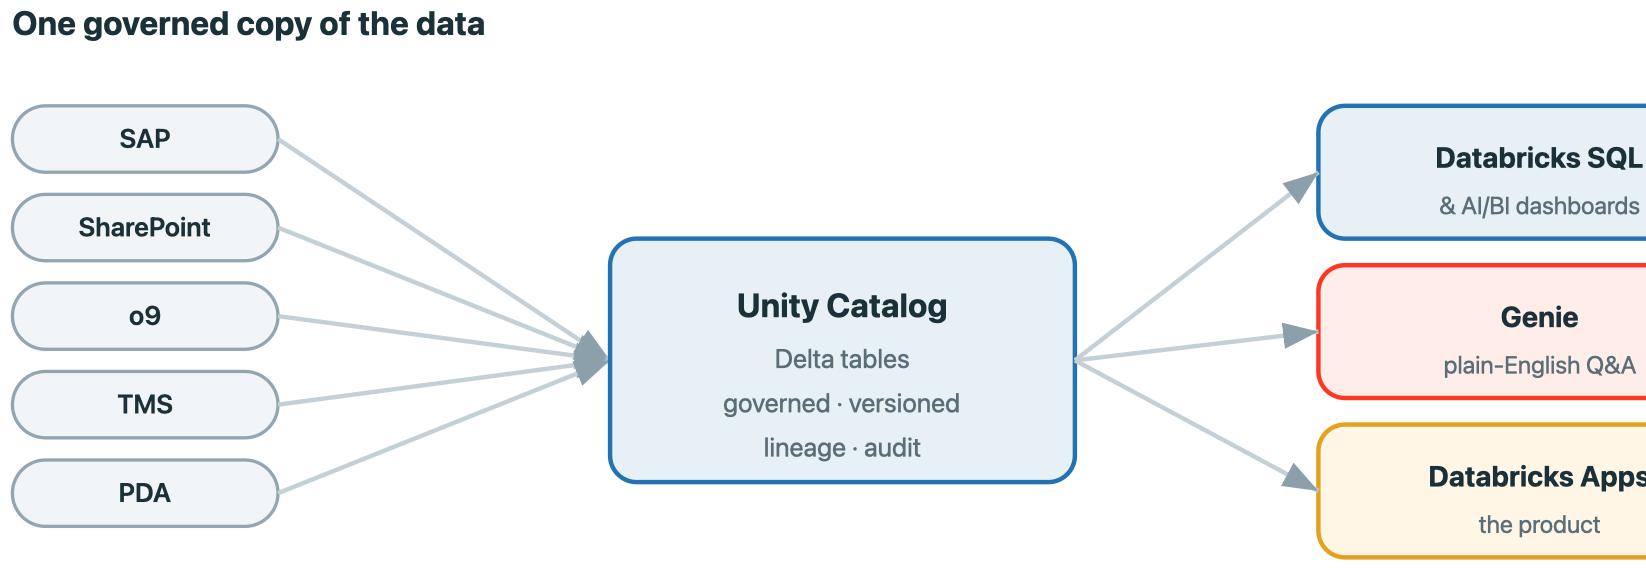

In [ ]:
def write_table(pdf, name):
    sdf = spark.createDataFrame(pdf)
    (sdf.write.format("delta").mode("overwrite")
        .option("overwriteSchema", "true").saveAsTable(f"{FQ}.{name}"))
    print(f"  wrote {FQ}.{name}  ({sdf.count()} rows)")

print("Writing Delta tables…")
for pdf, name in [(products, "products"), (distributors, "distributors"),
                  (orders, "orders"), (shipments, "shipments")]:
    write_table(pdf, name)
print("Done.")

## Step 4 · Validate

Row counts and one analytical join of the kind Genie will answer in Notebook 2.

In [ ]:
for t in ["products", "distributors", "orders", "shipments"]:
    print(f"{t:14s} {spark.table(f'{FQ}.{t}').count():>7,} rows")

In [ ]:
display(spark.sql(f"""
SELECT p.category AS segment, p.product_name, SUM(o.quantity_cases) AS total_cases
FROM {FQ}.orders o
JOIN {FQ}.products p     ON o.product_sku = p.product_sku
JOIN {FQ}.distributors d ON o.distributor_id = d.distributor_id
WHERE d.region = 'West' AND o.status = 'Delivered'
GROUP BY p.category, p.product_name
ORDER BY total_cases DESC LIMIT 5
"""))

## Step 5 · A Volume + knowledge-base PDFs (for an Agent Bricks Knowledge Assistant)

Genie answers questions about the **structured** tables above. But a lot of
supply-chain knowledge lives in **documents** — policies, SOPs, standards. Here
we land a few realistic PDFs in a **Unity Catalog Volume** so a later step can
point **Agent Bricks → Knowledge Assistant** at them and answer *"how do we…"*
questions with citations.

The documents are grounded in the **same** brands, regions, carriers, DCs, and
tiers as the tables above — so the structured (Genie) and unstructured
(Knowledge Assistant) views tell one coherent story, under one governance model.

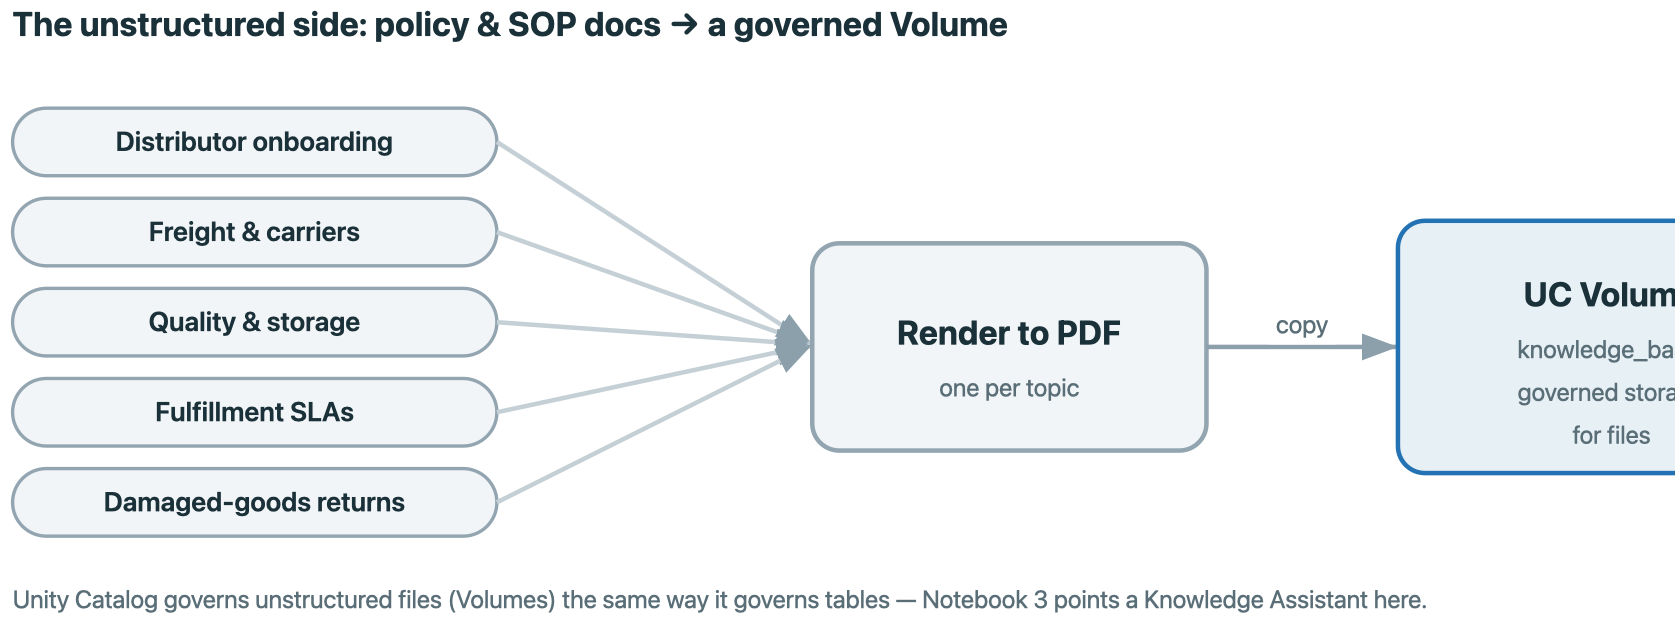

The flow mirrors the structured side (source → governed store), but for **files**:
we author a handful of policy/SOP documents, render each to a PDF, and copy them
into a **UC Volume**. Same catalog, same governance — just unstructured.

> The `%pip install` below may take a moment. It re-reads the `catalog`/`schema`
> widgets, so this step stands on its own even if the install resets the notebook.

In [ ]:
%pip install --quiet reportlab

In [ ]:
# Create the Volume (Unity Catalog-governed storage for unstructured files).
# Re-read widgets so this step is self-contained (the %pip above can reset state) —
# same username-appended schema as Step 1.
import re
CATALOG = dbutils.widgets.get("catalog").strip()
_user = spark.sql("SELECT current_user()").collect()[0][0]
_slug = re.sub(r"[^a-z0-9]+", "_", _user.split("@")[0].lower()).strip("_")
SCHEMA = f"{dbutils.widgets.get('schema').strip()}_{_slug}"
FQ = f"{CATALOG}.{SCHEMA}"

VOLUME = "knowledge_base"
spark.sql(f"CREATE VOLUME IF NOT EXISTS {FQ}.{VOLUME}")
VOL_PATH = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}"
print(f"Volume ready: {VOL_PATH}")

# The knowledge base: realistic supply-chain policy/SOP docs, grounded in the
# same brands, regions, carriers, DCs and tiers as the tables above.
DOCS = {
    "distributor_onboarding_and_credit_policy.pdf": {
        "title": "Distributor Onboarding and Credit Policy",
        "blocks": [
            ("p", "This policy governs how new distributors are onboarded to the Anheuser-Busch distribution network and how commercial credit limits are assigned and reviewed. It applies to all five US sales regions: Northeast, Southeast, Midwest, West, and Southwest."),
            ("h", "1. Commercial Tiers"),
            ("p", "Every distributor is assigned one of three commercial tiers at onboarding. The tier sets the default credit limit and the service level:"),
            ("b", "Premier: national and large regional accounts. Default credit limit $500,000. Priority freight and dedicated account management."),
            ("b", "Core: established mid-size distributors. Default credit limit $200,000. Standard service level."),
            ("b", "Independent: smaller or newly onboarded accounts. Default credit limit $75,000. Prepay or reduced terms until a payment history is established."),
            ("h", "2. Onboarding Steps"),
            ("p", "1) Submit the application with legal entity, primary city and state, and requested region. 2) Complete the credit review (Section 3). 3) Assign a distributor ID and tier. 4) Enable ordering in the assigned region. Onboarding targets completion within 10 business days."),
            ("h", "3. Credit Review and Payment Terms"),
            ("p", "Credit limits are reviewed at onboarding and annually thereafter. Standard payment terms are Net 30 from the delivery date. An order that would exceed a distributor's approved credit limit is held as Pending until the balance is cleared or a temporary increase is approved by the regional credit manager."),
            ("h", "4. Regions and Coverage"),
            ("p", "Each distributor is served from the regional distribution center for its region (see the Carrier and Freight SOP). A distributor's region determines its default origin DC and the destination region for its shipments."),
        ],
    },
    "carrier_and_freight_sop.pdf": {
        "title": "Carrier and Freight Standard Operating Procedure",
        "blocks": [
            ("p", "This SOP defines how outbound shipments are routed, which carriers are approved, and how on-time delivery performance is measured across the distribution network."),
            ("h", "1. Distribution Centers"),
            ("p", "Each sales region ships from a dedicated distribution center (DC):"),
            ("b", "Northeast: Newark DC"),
            ("b", "Southeast: Atlanta DC"),
            ("b", "Midwest: Chicago DC"),
            ("b", "West: Los Angeles DC"),
            ("b", "Southwest: Dallas DC"),
            ("h", "2. Approved Carriers"),
            ("p", "Freight is tendered to one of four approved carriers: Ironhorse Freight, BlueLine Logistics, Sunbelt Carriers, and Regional Express. Carrier selection balances lane coverage, cost, and historical on-time performance."),
            ("h", "3. On-Time Delivery Definition"),
            ("p", "A shipment is on-time when the actual delivery date is on or before the requested delivery date. Any delivery after the requested date is counted as late. The network target for on-time delivery is 90 percent; current performance runs near 82 percent, so late-lane root-cause reviews are conducted monthly."),
            ("h", "4. Freight Cost Drivers"),
            ("p", "Freight cost is driven primarily by shipping distance in miles and the number of cases moved, plus a fixed handling component. Freight cost per case is the standard efficiency metric and is reviewed by carrier and by lane."),
            ("h", "5. Shipping Windows"),
            ("p", "Orders typically leave the DC one to three days after the order date. The requested delivery date is set two to six days after the ship date, depending on distance and region."),
        ],
    },
    "product_quality_and_packaging_standards.pdf": {
        "title": "Product Quality and Packaging Standards",
        "blocks": [
            ("p", "These standards cover the beverage portfolio, packaging formats, and the storage and handling requirements that protect product quality from the distribution center to the point of sale."),
            ("h", "1. Commercial Segments"),
            ("p", "Products are grouped into five commercial segments: Value, Core, Premium, Craft and Import, and Non-Alcoholic. Segment is used for portfolio reporting and pricing."),
            ("h", "2. Packaging Formats"),
            ("p", "Approved selling formats (the case is the standard selling unit):"),
            ("b", "12oz Can 6-pack and 12oz Can 12-pack"),
            ("b", "16oz Can 4-pack"),
            ("b", "Bottle 6-pack"),
            ("b", "Half Keg (draft; not offered for Non-Alcoholic products)"),
            ("h", "3. Storage and Shelf Life"),
            ("p", "Packaged product should be stored between 35 and 45 degrees Fahrenheit, away from direct light, and rotated first-in-first-out. The recommended freshness window is 110 days from production for most brands. Kegs are perishable and must remain refrigerated at all times."),
            ("h", "4. Draft (Keg) Handling"),
            ("p", "Half kegs must be kept cold throughout the cold chain, handled upright, and never dropped. Draft lines at On-Premise accounts should be cleaned on a regular schedule to preserve taste quality."),
        ],
    },
    "order_fulfillment_and_service_level_policy.pdf": {
        "title": "Order Fulfillment and Service-Level Policy",
        "blocks": [
            ("p", "This policy describes how orders move from placement to delivery, the sales channels served, and the service-level expectations by tier."),
            ("h", "1. Order Lifecycle"),
            ("p", "Every order line moves through the following statuses: Pending (received, not yet released), In Transit (shipped, not yet delivered), Delivered (received by the distributor), and Cancelled. An order is fulfilled by exactly one shipment."),
            ("h", "2. Sales Channels"),
            ("p", "Orders are placed through two channels: Off-Premise (retail and grocery, for at-home consumption) and On-Premise (bars and restaurants, for on-site consumption). Roughly two-thirds of volume is Off-Premise."),
            ("h", "3. Service Levels by Tier"),
            ("p", "Premier accounts receive priority release and the tightest delivery windows. Core accounts follow the standard window. Independent accounts are served on standard terms once credit is confirmed. Regardless of tier, the on-time standard (delivery on or before the requested date) applies to every shipment."),
            ("h", "4. Cancellations"),
            ("p", "Orders may be cancelled before release without penalty. Once a shipment is In Transit it cannot be cancelled; any adjustment is handled as a return or claim under the Returns and Damaged Goods policy."),
        ],
    },
    "returns_damages_and_sustainability.pdf": {
        "title": "Returns, Damaged Goods and Sustainability Guidelines",
        "blocks": [
            ("p", "This document covers how product returns and damage claims are handled and the sustainability practices expected across packaging and distribution."),
            ("h", "1. Returns Eligibility"),
            ("p", "Product may be returned when it arrives damaged, is past its freshness window on arrival, or was shipped in error. Returns must be reported within 5 business days of delivery, referencing the order and shipment identifiers."),
            ("h", "2. Damaged Goods Claims"),
            ("p", "Damage discovered on receipt should be noted on the delivery record and photographed. Approved claims are credited to the distributor's account. Recurring damage on a lane triggers a carrier packaging and handling review."),
            ("h", "3. Keg Returns"),
            ("p", "Empty kegs are returnable assets and must be returned to the origin distribution center. Keg deposits are credited on return in good condition."),
            ("h", "4. Sustainability"),
            ("p", "Cans and bottles are fully recyclable, and distributors are asked to support recycling at retail and On-Premise accounts. Freight consolidation and full-truckload shipping are preferred to reduce distance-driven emissions and freight cost per case."),
        ],
    },
}
print(f"{len(DOCS)} documents defined.")

In [ ]:
# Render each document to a PDF and copy it into the Volume.
from reportlab.lib.pagesizes import LETTER
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
import html

_styles = getSampleStyleSheet()
_TITLE, _H2, _BODY = _styles["Title"], _styles["Heading2"], _styles["BodyText"]

def write_pdf(local_path, title, blocks):
    esc = lambda t: html.escape(t, quote=False)   # keep '&' etc. valid in reportlab markup
    doc = SimpleDocTemplate(local_path, pagesize=LETTER, title=title,
                            topMargin=0.9 * inch, bottomMargin=0.9 * inch,
                            leftMargin=1 * inch, rightMargin=1 * inch)
    story = [Paragraph(esc(title), _TITLE), Spacer(1, 0.2 * inch)]
    for kind, text in blocks:
        if kind == "h":
            story += [Spacer(1, 0.10 * inch), Paragraph(esc(text), _H2)]
        elif kind == "b":
            story.append(Paragraph("•  " + esc(text), _BODY))
        else:
            story.append(Paragraph(esc(text), _BODY))
        story.append(Spacer(1, 0.05 * inch))
    doc.build(story)

print("Writing knowledge-base PDFs…")
for fname, spec in DOCS.items():
    # Write straight into the UC Volume via its /Volumes FUSE path. This works on
    # serverless (which blocks local-filesystem + dbutils.fs.cp from file:/tmp) and
    # on classic compute alike — no local temp copy needed.
    write_pdf(f"{VOL_PATH}/{fname}", spec["title"], spec["blocks"])
    print(f"  wrote {fname}")
print(f"\nDone. {len(DOCS)} PDFs in {VOL_PATH}")

In [ ]:
# Verify what landed in the Volume.
files = dbutils.fs.ls(VOL_PATH)
for f in sorted(files, key=lambda x: x.name):
    print(f"  {f.name:52s} {f.size / 1024:6.1f} KB")
print(f"\n{len(files)} documents in {VOL_PATH}")

## ✅ Recap & what's next

You created four governed Delta tables under `{catalog}.{schema}`:
`products`, `distributors`, `orders`, `shipments` — plus a Unity Catalog
**Volume** (`knowledge_base`) holding a set of supply-chain **policy / SOP PDFs**.

**Key ideas**
- Source data lands as **Delta tables in Unity Catalog** — one governed copy.
- A small, clean, join-friendly schema is what makes **Genie** effective.
- Seeded generation → a reproducible dataset for the whole cohort.
- Unstructured docs live in a **UC Volume**, ready for the **Agent Bricks
  Knowledge Assistant** (Notebook 3) — structured *and* unstructured, one
  governance model.

**Next → Notebook 2:** add the descriptions, constraints, and example queries
that turn these tables into a high-quality **Genie agent**.